# Kaggle Dataset Explorer
## Schnelle Datenanalyse für Portfolio-Projekte

Dieses Notebook hilft dir dabei, Kaggle-Datasets schnell zu explorieren und zu entscheiden, ob sie für dein Portfolio-Projekt geeignet sind.

---

## 1. Setup & Daten laden



In [92]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from core.data import load_from_kaggle
import kagglehub


# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100



In [93]:
# ===== HIER DATASET-LINK EINFÜGEN =====
full_link = r"https://www.kaggle.com/datasets/madhankumar789/crop-yield-and-environmental-factors-2014-2023"
dataset_link = full_link.split("/datasets/")[-1]
# ======================================

destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

print(f"📦 Lade Dataset: {dataset_name}")
files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
)

print(f"✅ {len(files)} Datei(en) gefunden:")
for i, file in enumerate(files, 1):
    print(f"   {i}. {file}")

📦 Lade Dataset: crop-yield-and-environmental-factors-2014-2023
Destination directory '../data/raw\crop-yield-and-environmental-factors-2014-2023' already exists with files. Skipping download (replace=False).
✅ 1 Datei(en) gefunden:
   1. crop_yield_dataset.csv




## 2. Daten einlesen & erste Inspektion



In [94]:

# Erste CSV-Datei laden (oder bei Bedarf anpassen)
file_path = "/".join([destination, dataset_name, files[0]])
df = pd.read_csv(file_path)

print(f"📊 Geladene Datei: {files[0]}")
print(f"📏 Shape: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten\n")

df.sample(10)


📊 Geladene Datei: crop_yield_dataset.csv
📏 Shape: 36,520 Zeilen × 12 Spalten



,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
2106,2014-07-30,Sugarcane,Saline,8.00,31.444816,68.555184,8.485255,84.5,66.0,54.0,24.786482,17.041667
20320,2019-07-26,Wheat,Saline,8.00,26.202410,73.797590,13.346602,71.5,55.0,40.5,22.001516,13.916667
26236,2021-03-08,Sugarcane,Saline,8.00,29.010856,70.989144,13.259894,84.5,66.0,54.0,37.188837,17.041667
15203,2018-03-01,Barley,Saline,8.00,27.521972,72.478028,13.366991,65.0,55.0,45.0,13.495861,13.750000
11642,2017-03-10,Rice,Sandy,6.75,33.143406,66.856594,7.011546,65.0,48.0,33.0,9.475319,42.583333
21103,2019-10-12,Barley,Peaty,5.50,10.755104,80.000000,9.698662,55.0,45.0,35.0,4.304131,22.500000
16416,2018-06-30,Sugarcane,Sandy,6.75,35.747852,64.252148,11.405356,65.0,48.0,36.0,0.000000,43.458333
29173,2021-12-27,Barley,Sandy,6.75,17.787365,80.000000,10.103617,50.0,40.0,30.0,42.965840,35.000000
22840,2020-04-03,Wheat,Peaty,5.50,27.110603,72.889397,7.714552,60.5,45.0,31.5,16.270011,22.833333
20985,2019-09-30,Cotton,Loamy,6.50,18.530679,80.000000,15.330577,77.0,66.0,60.0,79.024134,67.666667




---

## 3. Datenqualität & Struktur



In [95]:

print("=" * 80)
print("📋 DATENÜBERSICHT")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"🔄 Duplikate: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"💾 Speichernutzung: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



📋 DATENÜBERSICHT

🔢 Dimensionen: 36,520 Zeilen × 12 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 8.37 MB


In [96]:
# Detaillierte Spaltenübersicht
column_info = pd.DataFrame({
    "Datentyp": df.dtypes,
    "Fehlende Werte": df.isnull().sum(),
    "Fehlend %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Werte": df.nunique(),
    "Beispielwerte": [df[col].dropna().sample(min(3, df[col].notna().sum())).tolist() 
                      if df[col].notna().sum() > 0 else [] 
                      for col in df.columns]
})

column_info = column_info.sort_values("Fehlend %", ascending=False)
column_info


,Datentyp,Fehlende Werte,Fehlend %,Unique Werte,Beispielwerte
Date,object,0,0.0,3652,"[2018-08-23, 2015-10-20, 2021-11-23]"
Crop_Type,object,0,0.0,10,"[Wheat, Soybean, Soybean]"
Soil_Type,object,0,0.0,5,"[Saline, Saline, Sandy]"
Soil_pH,float64,0,0.0,5,"[6.25, 6.5, 6.75]"
Temperature,float64,0,0.0,36520,"[22.856194819523456, 36.485255394357694, 30.77..."
Humidity,float64,0,0.0,22906,"[75.28221646667876, 75.55981076870785, 77.0117..."
Wind_Speed,float64,0,0.0,36520,"[14.764794675875372, 7.077819529245335, 7.8090..."
N,float64,0,0.0,20,"[66.0, 50.0, 71.5]"
P,float64,0,0.0,16,"[72.0, 48.0, 55.00000000000001]"
K,float64,0,0.0,18,"[31.5, 38.5, 44.0]"




---

## 4. Numerische Variablen analysieren



In [97]:

# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



📊 9 numerische Spalten gefunden



,count,mean,std,min,25%,50%,75%,max
Soil_pH,36520.0,6.60,0.82,5.50,6.25,6.50,6.75,8.00
Temperature,36520.0,23.81,8.92,-3.54,17.17,22.90,30.25,54.15
Humidity,36520.0,74.26,6.77,45.85,69.75,77.10,80.00,80.00
Wind_Speed,36520.0,10.02,3.00,-3.39,7.99,10.00,12.04,22.61
N,36520.0,66.01,10.89,45.00,58.50,65.00,71.50,91.00
P,36520.0,53.01,8.81,36.00,45.00,54.00,60.00,72.00
K,36520.0,42.02,8.54,27.00,35.00,42.00,49.50,60.00
Crop_Yield,36520.0,26.88,25.74,0.00,0.00,23.37,46.42,136.71
Soil_Quality,36520.0,37.52,17.70,13.29,22.50,35.58,49.29,74.33


In [98]:
# Negative Wind Speed!
neg_wind = df[df['Wind_Speed'] < 0]
print(f"Number of rows with negative wind speed: {len(neg_wind)}, Percentage: {len(neg_wind) / len(df) * 100:.2f}%")
n_negative = (df['Wind_Speed'] < 0).sum()
print(f"Clipping {n_negative} negative Wind_Speed values to 0")
df['Wind_Speed'] = df['Wind_Speed'].clip(lower=0)

Number of rows with negative wind speed: 15, Percentage: 0.04%
Clipping 15 negative Wind_Speed values to 0


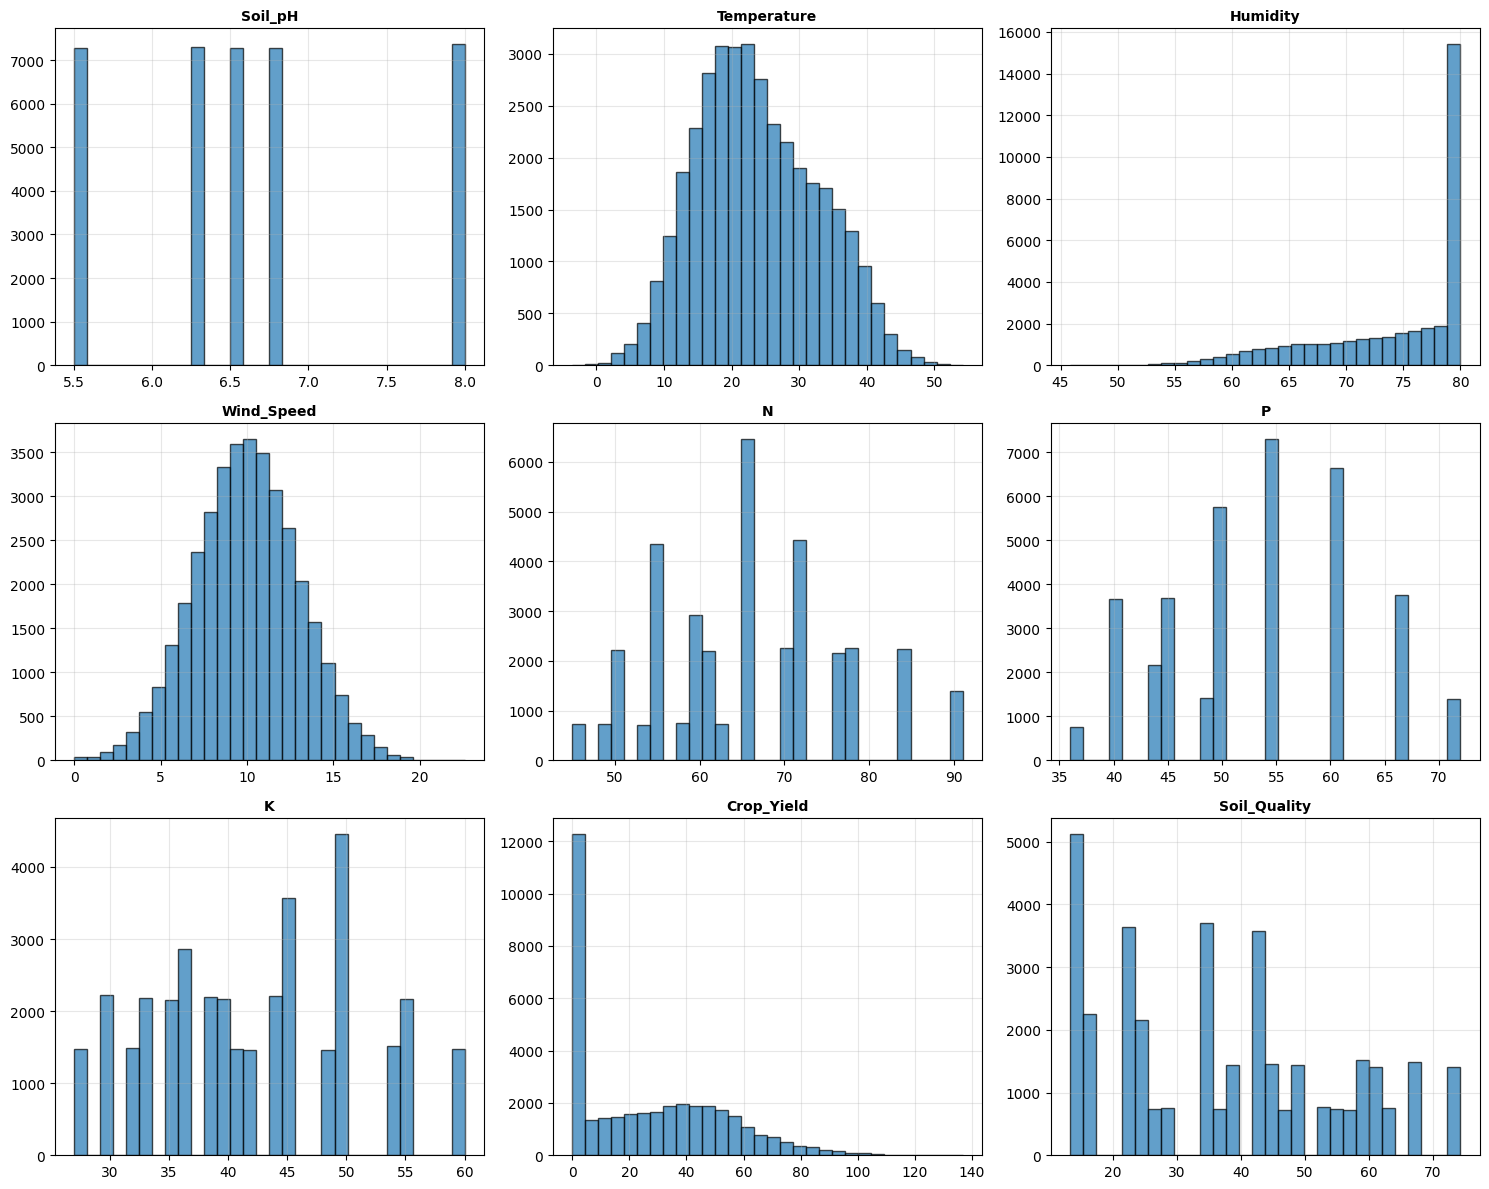

In [99]:
# Verteilungen der numerischen Variablen
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Leere Subplots ausblenden
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


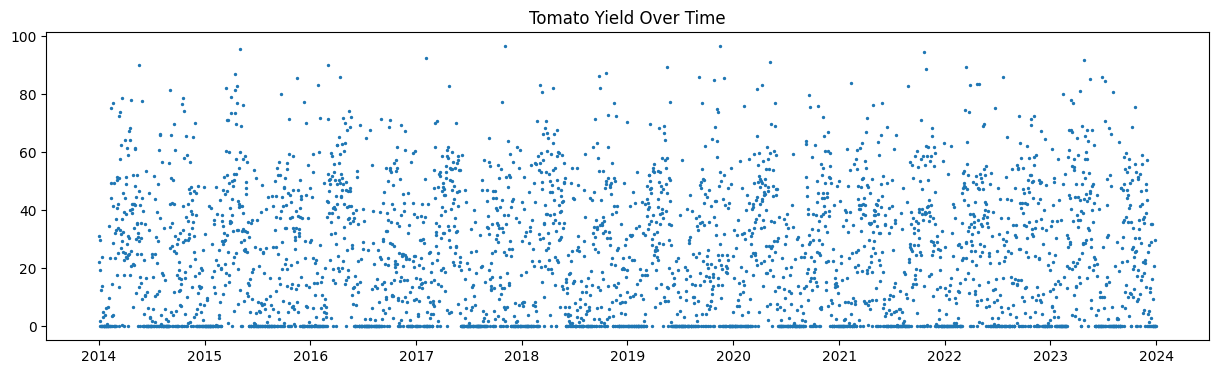

Month
1     0.503226
2     0.475177
3     0.058065
4     0.036667
5     0.045161
6     0.496667
7     0.496774
8     0.561290
9     0.163333
10    0.138710
11    0.110000
12    0.487097
Name: Crop_Yield, dtype: float64


In [106]:
# Zero spike in crop yield for example Tomato
df['Date'] = pd.to_datetime(df['Date'])
tomato = df[df['Crop_Type'] == 'Tomato'].copy()

plt.figure(figsize=(15,4))
plt.scatter(tomato['Date'], tomato['Crop_Yield'], s=2)
plt.title('Tomato Yield Over Time')
plt.show()

tomato['Month'] = tomato['Date'].dt.month

is_zero = tomato['Crop_Yield'] == 0
zero_rate_by_month = is_zero.groupby(tomato['Month']).mean()
print(zero_rate_by_month)

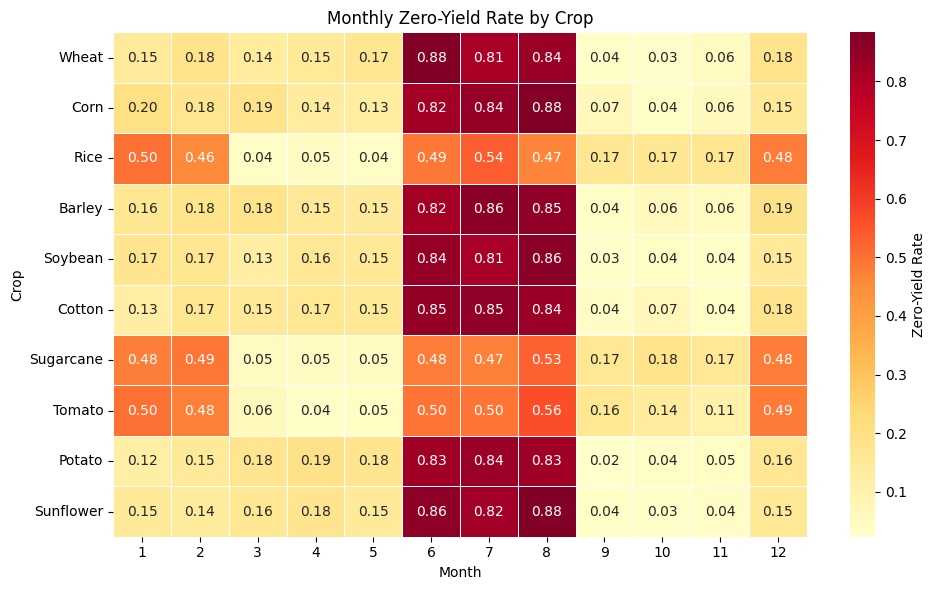

In [112]:
# Overview for all crops
crops = df['Crop_Type'].unique()

zero_rates = {}
for crop in crops:
    crop_df = df[df['Crop_Type'] == crop].copy()
    crop_df['Month'] = crop_df['Date'].dt.month
    is_zero = crop_df['Crop_Yield'] == 0
    monthly_rates = is_zero.groupby(crop_df['Month']).mean()
    zero_rates[crop] = monthly_rates

df_heat = pd.DataFrame(zero_rates).T
df_heat.columns.name = 'Month'

plt.figure(figsize=(10, 6))
sns.heatmap(df_heat, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Zero-Yield Rate'})
plt.title('Monthly Zero-Yield Rate by Crop')
plt.xlabel('Month')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

From the heatmap one can clearly see two kinds of crops:
    - unimodal crops with high zero rates in summer (wheat, corn, barley, soybean, cotton, potato, and sunflower)
    - bimodal crops with high zero rates (smaller scale) in summer and winter (rice, sugarcane, and tomato)
This will be considered for feature engineering. 

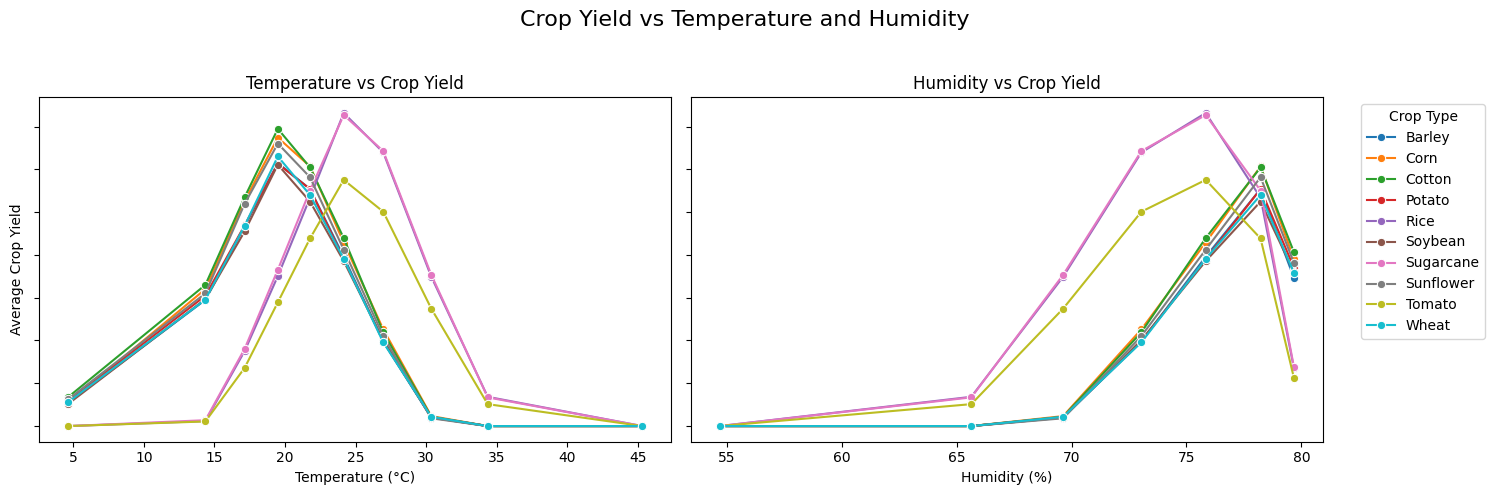

In [113]:
# Humidity and Temperature vs Crop Yield
df['humidity_bin'] = pd.qcut(df['Humidity'], q=10, duplicates='drop')

# Numeric midpoint for each bin, useful for plotting as a continuous x-axis
df['humidity_bin_mid'] = df['humidity_bin'].apply(lambda x: x.mid).astype(float)
binned = df.groupby(['Crop_Type', 'humidity_bin_mid'])['Crop_Yield'].mean().reset_index()

df['temp_bin'] = pd.qcut(df['Temperature'], q=10, duplicates='drop')
df['temp_bin_mid'] = df['temp_bin'].apply(lambda x: x.mid).astype(float)

binned_temp = df.groupby(['Crop_Type', 'temp_bin_mid'])['Crop_Yield'].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.lineplot(x='temp_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o', data=binned_temp, ax=ax[0], legend=False)
sns.lineplot(x='humidity_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o', data=binned, ax=ax[1])
fig.suptitle('Crop Yield vs Temperature and Humidity', fontsize=16)
ax[0].set_title('Temperature vs Crop Yield')
ax[0].set_xlabel('Temperature (°C)')
ax[0].set_ylabel('Average Crop Yield')
ax[1].set_title('Humidity vs Crop Yield')
ax[1].set_xlabel('Humidity (%)')
ax[1].set_yticklabels([])  # Hide y-tick labels for the second plot
ax[1].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout(rect=[0, 0, 1, 0.95])

The same two kinds of crops is also visible here : Rice-Sugarcane-Tomato vs. the rest.

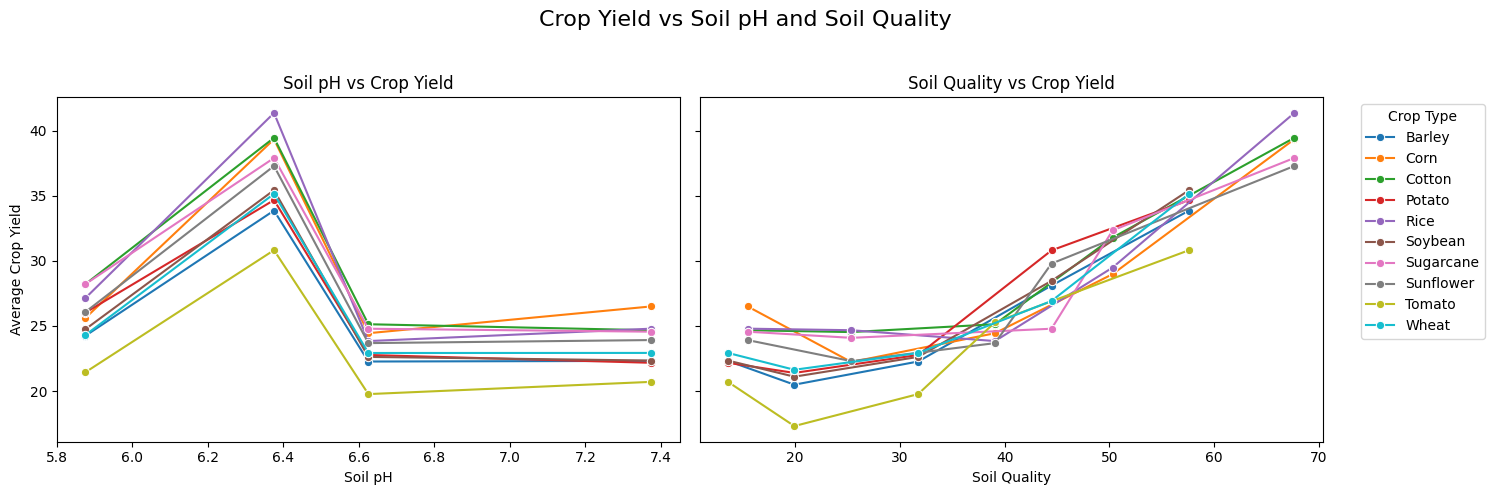

In [114]:
# Soil pH vs Crop Yield
df['pH_bin'] = pd.qcut(df['Soil_pH'], q=10, duplicates='drop')

# Numeric midpoint for each bin
df['pH_bin_mid'] = df['pH_bin'].apply(lambda x: x.mid).astype(float)
binned = df.groupby(['Crop_Type', 'pH_bin_mid'])['Crop_Yield'].mean().reset_index()

df['soil_bin'] = pd.qcut(df['Soil_Quality'], q=10, duplicates='drop')
df['soil_bin_mid'] = df['soil_bin'].apply(lambda x: x.mid).astype(float)

binned_soil = df.groupby(['Crop_Type', 'soil_bin_mid'])['Crop_Yield'].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.lineplot(x='pH_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o',  data=binned, ax=ax[0], legend=False)
sns.lineplot(x='soil_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o', data=binned_soil, ax=ax[1])
fig.suptitle('Crop Yield vs Soil pH and Soil Quality', fontsize=16)
ax[1].set_title('Soil Quality vs Crop Yield')
ax[1].set_xlabel('Soil Quality')
ax[1].set_ylabel('Average Crop Yield')
ax[0].set_title('Soil pH vs Crop Yield')
ax[0].set_xlabel('Soil pH')
ax[0].set_ylabel('Average Crop Yield')
ax[1].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.tight_layout(rect=[0, 0, 1, 0.95])

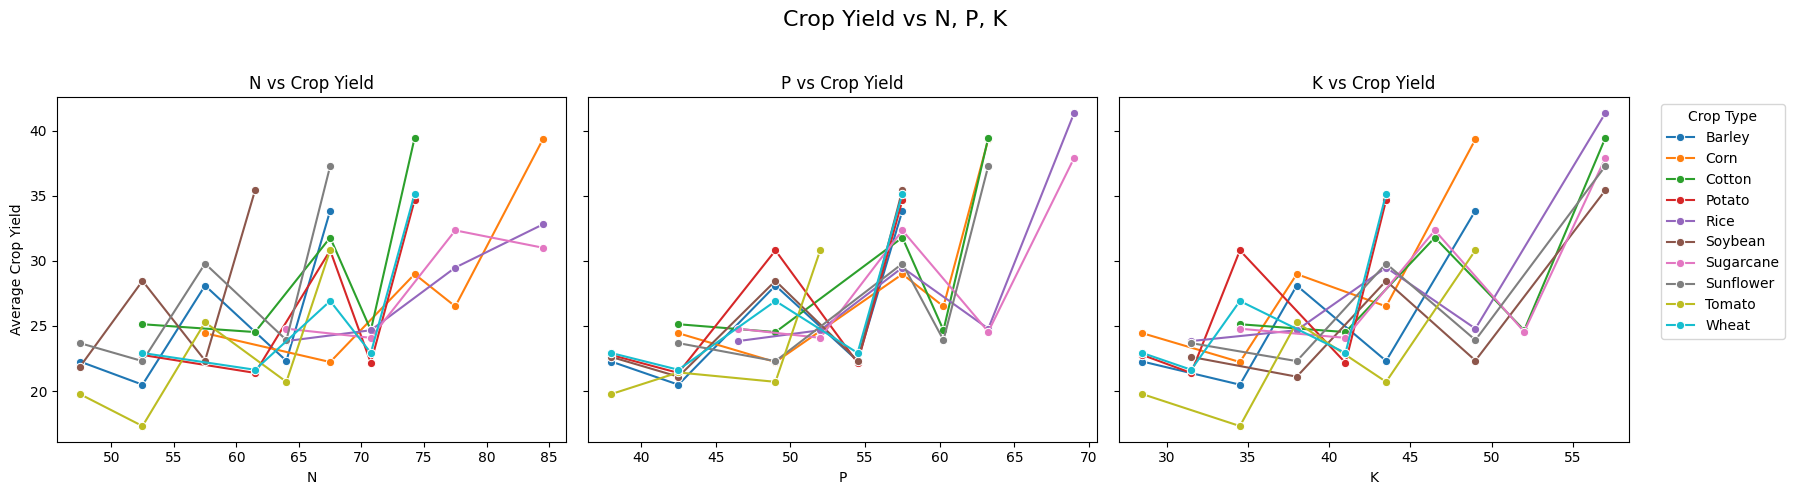

In [115]:
for nutrient in ['N', 'P', 'K']:
    bins = pd.qcut(df[nutrient], q=10, duplicates='drop')
    df[f'{nutrient}_bin_mid'] = bins.apply(lambda x: x.mid).astype(float)

fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, nutrient in enumerate(['N', 'P', 'K']):
    binned_nutrient = df.groupby(['Crop_Type', f'{nutrient}_bin_mid'])['Crop_Yield'].mean().reset_index()
    legend = (i == 2)  # only show legend on last plot
    sns.lineplot(x=f'{nutrient}_bin_mid', y='Crop_Yield', hue='Crop_Type', marker='o',
                 data=binned_nutrient, ax=ax[i], legend=legend)
    ax[i].set_title(f'{nutrient} vs Crop Yield')
    ax[i].set_xlabel(nutrient)

ax[0].set_ylabel('Average Crop Yield')
ax[2].legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Crop Yield vs N, P, K', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])



---

## 5. Kategorische Variablen analysieren



In [116]:

# Kategorische Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"🏷️ {len(categorical_cols)} kategorische Spalten gefunden\n")
    
    cat_summary = pd.DataFrame({
        "Spalte": categorical_cols,
        "Unique Werte": [df[col].nunique() for col in categorical_cols],
        "Häufigste Werte": [df[col].value_counts().head(3).to_dict() for col in categorical_cols]
    })
    
    display(cat_summary)
else:
    print("⚠️ Keine kategorischen Spalten gefunden")


🏷️ 6 kategorische Spalten gefunden



,Spalte,Unique Werte,Häufigste Werte
0,Crop_Type,10,"{'Wheat': 3652, 'Corn': 3652, 'Rice': 3652}"
1,Soil_Type,5,"{'Saline': 7361, 'Clay': 7300, 'Loamy': 7288}"
2,humidity_bin,7,"{(79.356, 80.0]: 14608, (63.494, 67.77]: 3652,..."
3,temp_bin,10,"{(-3.541, 12.776]: 3652, (12.776, 15.94]: 3652..."
4,pH_bin,4,"{(5.499, 6.25]: 14586, (6.75, 8.0]: 7361, (6.2..."
5,soil_bin,10,"{(42.583, 46.375]: 4289, (13.917, 17.042]: 370..."


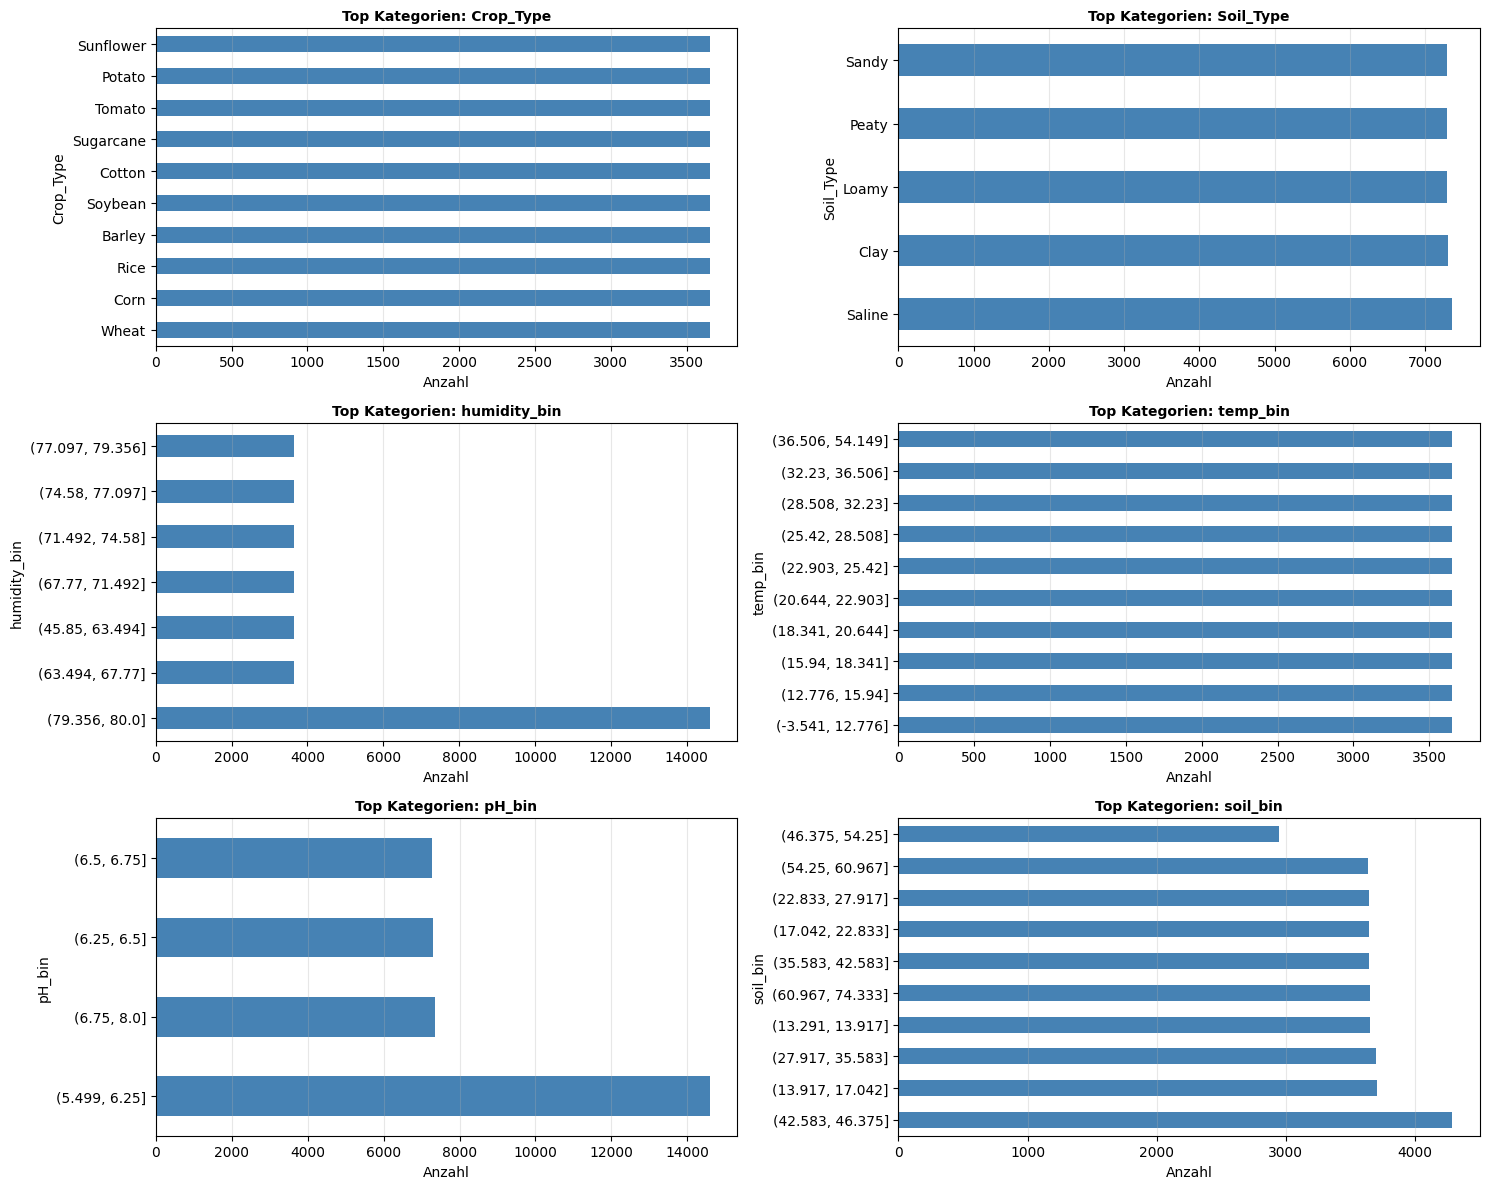

In [117]:
# Top-Kategorien visualisieren (für Spalten mit wenigen Unique-Werten)
if categorical_cols:
    low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= 20]
    
    if low_cardinality_cols:
        n_cols = min(2, len(low_cardinality_cols))
        n_rows = (len(low_cardinality_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if len(low_cardinality_cols) > 1 else [axes]
        
        for idx, col in enumerate(low_cardinality_cols):
            ax = axes[idx]
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'Top Kategorien: {col}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Anzahl')
            ax.grid(alpha=0.3, axis='x')
        
        # Leere Subplots ausblenden
        for idx in range(len(low_cardinality_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()




---

## 6. Korrelationsanalyse



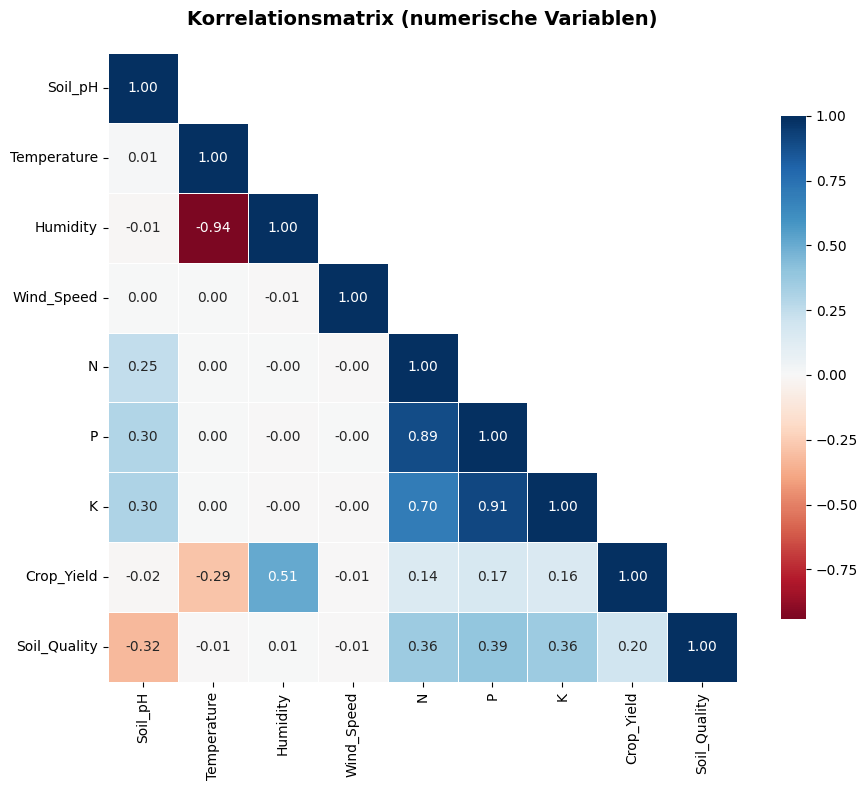


🔗 Stärkste Korrelationen (|r| > 0.5):



,Variable 1,Variable 2,Korrelation
0,Temperature,Humidity,-0.942212
4,P,K,0.906531
2,N,P,0.892132
3,N,K,0.700894
1,Humidity,Crop_Yield,0.511841


In [118]:

if len(numeric_cols) > 1:
    # Korrelationsmatrix
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Obere Dreiecksmatrix maskieren
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        fmt='.2f',
        cmap='RdBu', 
        center=0, 
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Korrelationsmatrix (numerische Variablen)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Stärkste Korrelationen finden
    print("\n🔗 Stärkste Korrelationen (|r| > 0.5):\n")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Korrelation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Korrelation', 
                                                        key=abs, 
                                                        ascending=False)
        display(corr_df)
    else:
        print("Keine starken Korrelationen gefunden.")
else:
    print("⚠️ Nicht genügend numerische Variablen für Korrelationsanalyse")




---

## 7. Fehlende Werte visualisieren



In [119]:

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_data) * 0.4)))
    
    missing_percent = (missing_data / len(df) * 100)
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    
    ax.set_title('Fehlende Werte pro Spalte', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prozent fehlend (%)')
    ax.grid(alpha=0.3, axis='x')
    
    # Werte als Text hinzufügen
    for i, v in enumerate(missing_percent):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine fehlenden Werte im Dataset!")


✅ Keine fehlenden Werte im Dataset!




---

## 8. Zusammenfassung & Bewertung



In [120]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")


📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT
Datengröße.................... ✅ Gut
Vollständigkeit............... ✅ 100.0%
Duplikate..................... ✅ Keine
Variablenvielfalt............. ✅ 23 Spalten
Numerische Features........... ✅ 9 Spalten
Kategorische Features......... ✅ 6 Spalten

💡 EMPFEHLUNG:
✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!

📌 Nächste Schritte:
   1. Definiere deine Forschungsfrage
   2. Identifiziere relevante Features
   3. Plane deine Analysestrategie
   4. Beginne mit Feature Engineering & Modeling
